# Model Training and Evaluation

After completing data preprocessing, feature engineering, and feature selection, machine learning models are trained to predict football match outcomes.

Since this is a multiclass classification problem, several classification algorithms are evaluated and compared. The models are assessed using common classification metrics to determine which one generalizes best to unseen data.

The following steps are performed:

1. Split the dataset into training and testing sets.
2. Train multiple classification models.
3. Evaluate each model using classification metrics.
4. Compare the performance of all models.

## Import Libraries

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

sns.set_theme(style="whitegrid")

## Load Dataset

In [4]:
df_selected = pd.read_csv("../data/engineered_data.csv")

df_selected.head()

,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,...,away_avg_goals_conceded,away_avg_team_rating,home_goal_difference,away_goal_difference,rating_difference,goal_difference_difference,home_avg_rest_days,home_recent_cup_ratio,away_recent_cup_ratio,match_result
0,636,0,468196.0,468200.0,5.199840,3.694033,5.131156,3.193161,4.080169,3.898775,...,0.9,8.561214,0.3,0.7,-3.064844,-0.4,48.1,0.0,0.5,0
1,752,0,516788.0,22169161.0,3.671610,6.121228,3.320450,5.766069,4.118071,4.223164,...,1.4,5.287316,-0.1,-0.6,3.153522,0.5,33.5,0.0,0.0,2
2,734,0,2510608.0,456313.0,6.825194,4.053167,5.293940,4.725164,7.776850,4.167290,...,1.1,7.620071,0.2,1.0,-0.775358,-0.8,42.0,0.0,0.0,1
3,743,0,1552508.0,465797.0,5.998800,6.024042,4.508125,4.960117,5.867100,4.351000,...,2.0,5.818128,0.5,0.4,1.631795,0.1,34.7,0.0,0.1,0
4,705,0,429958.0,426870.0,5.535514,4.848225,6.279472,4.178193,7.449917,3.002752,...,1.0,5.983338,0.4,0.8,1.096297,-0.4,34.8,0.0,0.0,2


## Train and Test Split

The dataset is divided into two subsets:

- **Training set (80%)** for training the models.
- **Test set (20%)** for evaluating the final model on unseen data.

A stratified split is used to preserve the original distribution of the target classes in all subsets.

In [5]:
X = df_selected.drop(columns=["match_result"])
y = df_selected["match_result"]

# Split into training (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Set:   {X_train.shape}")
print(f"Test Set:       {X_test.shape}")

Training Set:   (88736, 50)
Test Set:       (22185, 50)


## Logistic Regression

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test)

c:\Users\satia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## Decision Tree

In [7]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

## Random Forest

In [8]:
rf = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## KNN

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test)

c:\Users\satia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [10]:
def evaluate(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1": f1_score(y_true, y_pred, average="weighted")
    }

In [11]:
results = pd.DataFrame({
    "Logistic Regression": evaluate(y_test, lr_pred),
    "Decision Tree": evaluate(y_test, dt_pred),
    "Random Forest": evaluate(y_test, rf_pred),
    "KNN": evaluate(y_test, knn_pred)
}).T

results

,Accuracy,Precision,Recall,F1
Logistic Regression,0.329277,0.366566,0.329277,0.329532
Decision Tree,0.389362,0.390364,0.389362,0.389837
Random Forest,0.430471,0.414713,0.430471,0.419895
KNN,0.279062,0.359372,0.279062,0.214819


In [12]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.41      0.44      0.42      7034
           1       0.27      0.19      0.22      5529
           2       0.50      0.57      0.53      9622

    accuracy                           0.43     22185
   macro avg       0.39      0.40      0.39     22185
weighted avg       0.41      0.43      0.42     22185



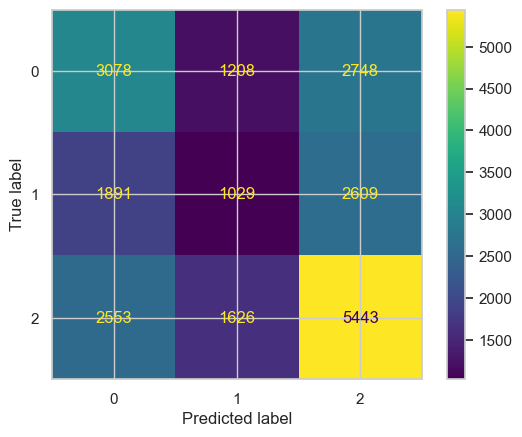

In [13]:
ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

In [14]:
scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Cross-validation accuracy:", scores.mean())



Cross-validation accuracy: 0.431820258066199
